### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
* Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

* Calcola la media del consumo di birra, vino, e distillati

* Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

* Trova il paese con il valore massimo di alcohol_index

* Filtra solo i paesi che consumano più di 100 birre all’anno

Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

Crea un line plot con wine_servings ordinato per paese (usa sort_values)

                country  beer_servings  spirit_servings  wine_servings  \
15              Belarus            142              373             42   
98            Lithuania            343              244             56   
3               Andorra            245              138            312   
68              Grenada            199              438             28   
61               France            127              151            370   
45       Czech Republic            361              170            134   
141  Russian Federation            247              326             73   
99           Luxembourg            236              133            271   
155            Slovakia            196              293            116   
81              Ireland            313              118            165   

     total_litres_of_pure_alcohol  
15                           14.4  
98                           12.9  
3                            12.4  
68                           11.9  
61   

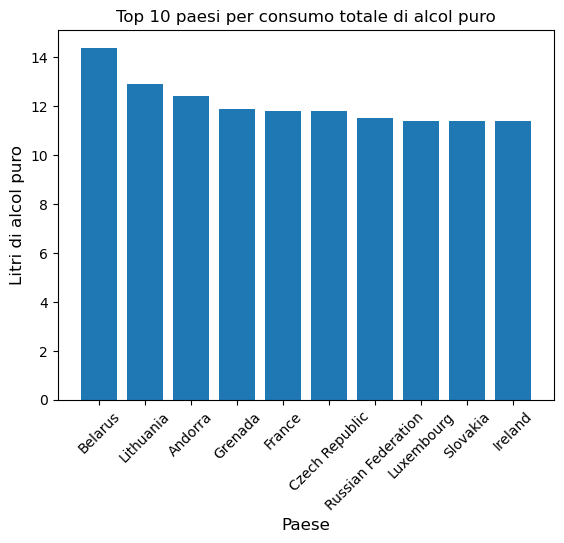

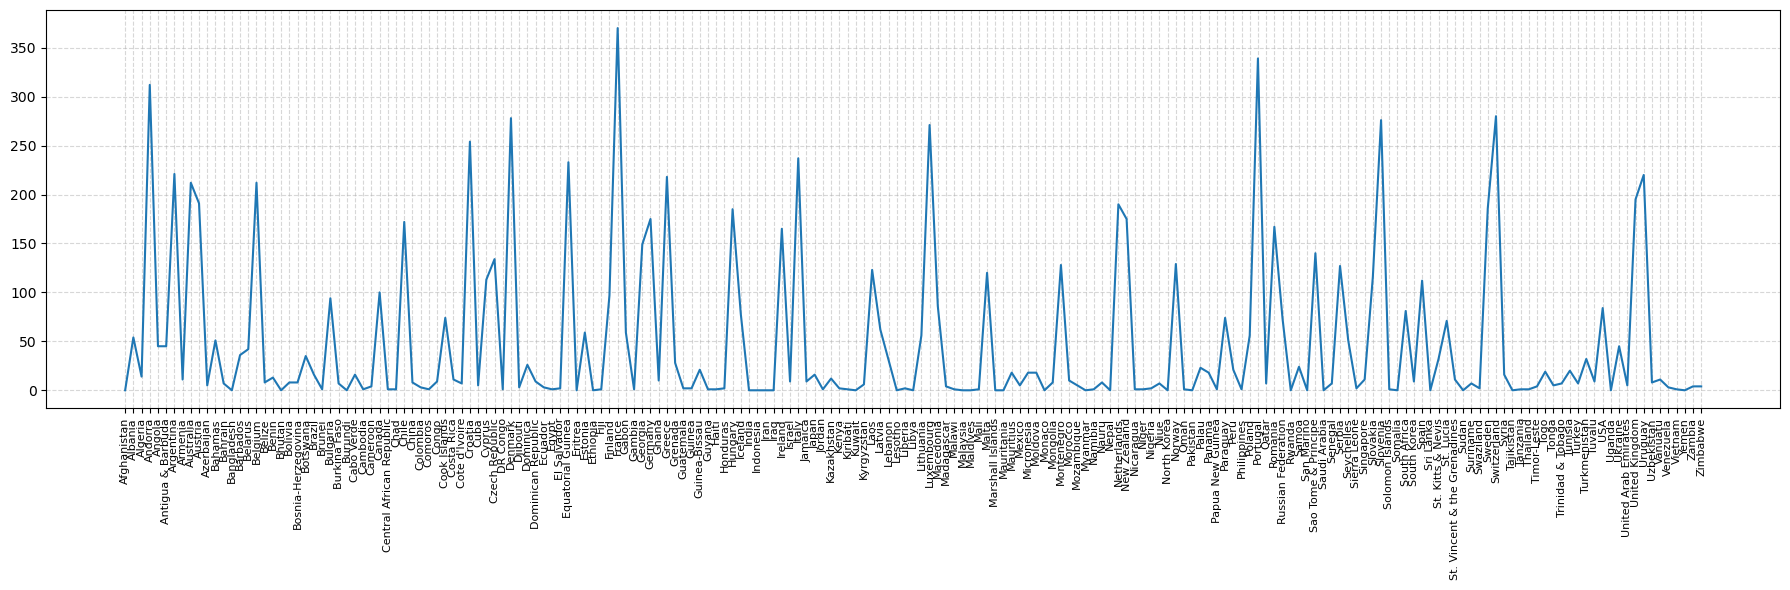

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("https://raw.githubusercontent.com/fivethirtyeight/data/master/alcohol-consumption/drinks.csv")
df
#ES1
top_10 = df.sort_values(by="total_litres_of_pure_alcohol", ascending = False).head(10)
print(top_10)
#ES2
media_birra = df["beer_servings"].mean()
media_vino = df["wine_servings"].mean()
media_dist = df["spirit_servings"].mean()
print(f"Media birra: {media_birra}, media vino: {media_vino}, media distillati: {media_dist}")
#ES3
df["alcohol_index"] = (df["beer_servings"]+df["spirit_servings"]+df["wine_servings"])/3
#ES4
indice_massimo = df["alcohol_index"].idxmax()
paese_max = df.loc[indice_massimo, "country"]
print("paese con valore massimo di alchol_index :", paese_max)
#ES5
filtro = df[df["beer_servings"] >100]
print("paesi che consumano più di 100 birre all'anno: ", len(filtro))
#ES6
import matplotlib.pyplot as plt
import seaborn as sns
plt.bar(top_10["country"], top_10["total_litres_of_pure_alcohol"])
plt.title("Top 10 paesi per consumo totale di alcol puro")
plt.xlabel("Paese", fontsize = 12)
plt.ylabel("Litri di alcol puro", fontsize = 12)
plt.xticks(rotation=45) #per non far accavallare i nomi sull'asse x
#ES7
df_ordinato = df.sort_values(by="country")
plt.figure(figsize=(18,6))
plt.plot(df_ordinato["country"], df_ordinato["wine_servings"])
plt.xticks(rotation=90, fontsize = 8)
plt.grid(True, linestyle = "--", alpha = 0.5)
plt.tight_layout()
plt.show()


### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

c:\Users\auror\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


             stipendio_medio  offerte_totali  stipendio_minimo  \
job_country                                                      
Afghanistan              NaN               0               NaN   
Albania         79472.500000               5           43200.0   
Algeria         44550.000000               2           44100.0   
Angola                   NaN               0               NaN   
Argentina      105212.343750              32           45000.0   
Armenia         78757.000000               6           45000.0   
Australia      118987.574324              74           20000.0   
Austria        105269.194444              18           53014.0   
Azerbaijan      72000.000000               1           72000.0   
Bahamas        201511.619048              21          173500.0   

             stipendio_massimo  
job_country                     
Afghanistan                NaN  
Albania               157500.0  
Algeria                45000.0  
Angola                     NaN  
Argentina

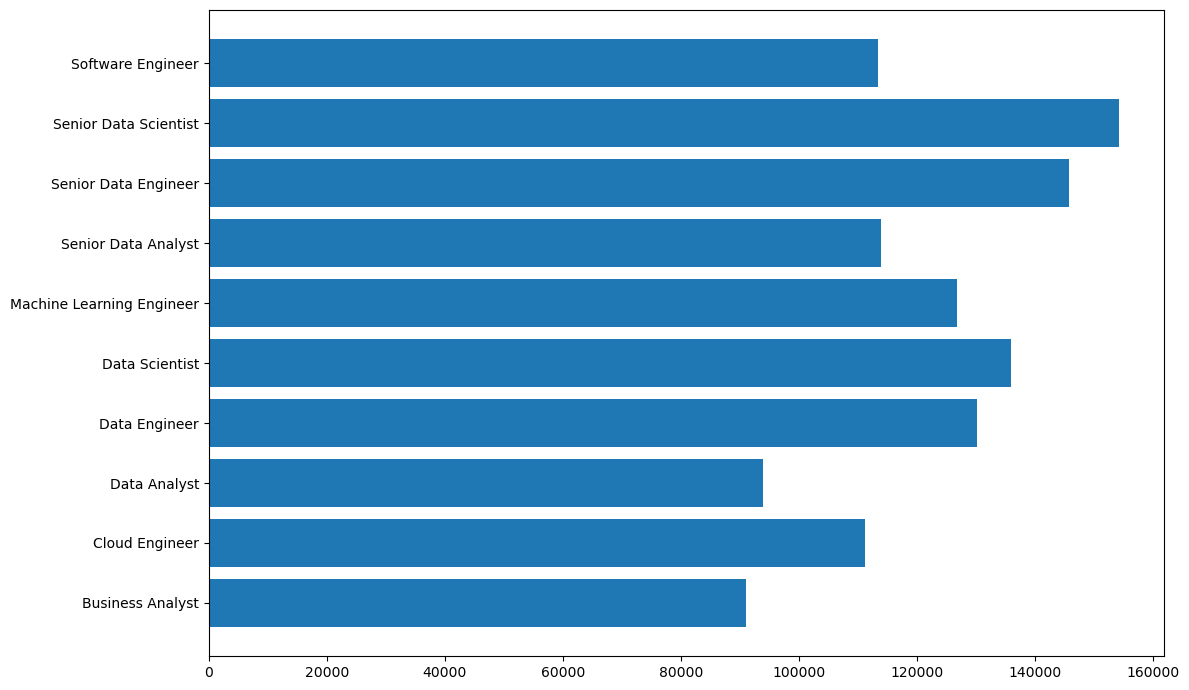

In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
dataset

analisi = df.groupby("job_country")["salary_year_avg"].agg(
    stipendio_medio="mean",
    offerte_totali="count",
    stipendio_minimo="min",
    stipendio_massimo="max"
)
print(analisi.head(10))
stipendio_per_titolo = df.dropna(subset=['salary_year_avg']).groupby('job_title_short')['salary_year_avg'].mean()

plt.figure(figsize=(12,7))
plt.barh(stipendio_per_titolo.index, stipendio_per_titolo.values)
plt.tight_layout()
plt.show()

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [5]:
#analisi
analisi = df.groupby("day")["total_bill"].agg(["count"])
print("Analisi vendite giornaliere: ",analisi)
#creazione colonna
df["conto_per_persona"] = df["total_bill"]/df["size"]
#giorno con il conto medio più alto
conto_medio_alto = df.groupby("day")["total_bill"].mean().idxmax()
print("giorno con il conto medio più alto :", conto_medio_alto)

Analisi vendite giornaliere:        count
day        
Fri      19
Sat      87
Sun      76
Thur     62
giorno con il conto medio più alto : Sun
